In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
import os
from matplotlib import font_manager
import warnings
from tqdm import tqdm
import textwrap
import math
from matplotlib import font_manager
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

Loading data

In [2]:
# Path to your CSV file
csv_path = r"D:\Projects\Sanskrit-OCR\dataset.csv"

# Load the CSV
data = pd.read_csv(csv_path)

# Check basic info
print(f"✅ Loaded {len(data)} samples from CSV")
print(data.head())

✅ Loaded 496 samples from CSV
                                          image_path  \
0  D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-I...   
1  D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-I...   
2  D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-I...   
3  D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-I...   
4  D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-I...   

                                                text  
0  THE WORKS OF\n\nSri Sankaracharya\n\nSRI VANI ...  
1  परिग्रहण सं. १०३६३\nग्रन्थालय, के. उ. ति. शि. ...  
2  THE WORKS OF\nSRI SANKARACHARYA\nVOLUME 1\n\nS...  
3  परिग्रहण सं. १०३६३\nग्रन्थालय, के. उ. ति. शि. ...  
4  CONTENTS\nBRAHMASUTRA- BHASHYA \t- -\tPAGE\nCH...  


EDA


In [3]:
# 1️⃣ Check for missing or empty values
# -------------------------------------------------------------------------
print("\n🔍 Missing Value Check:")
print(data.isnull().sum())

empty_texts = data[data['text'].astype(str).str.strip() == ""]
print(f"\n⚠️ Empty text entries: {len(empty_texts)}")


🔍 Missing Value Check:
image_path    0
text          2
dtype: int64

⚠️ Empty text entries: 0


In [4]:
# Remove rows where text is NaN or empty
data = data.dropna(subset=['text'])
data = data[data['text'].astype(str).str.strip() != '']

print(f"✅ Cleaned dataset now has {len(data)} rows (removed missing text entries)")


✅ Cleaned dataset now has 494 rows (removed missing text entries)



📏 Text Statistics:
        char_count  word_count
count   494.000000  494.000000
mean   1654.621457  182.690283
std     610.860418   75.890703
min      23.000000    3.000000
25%    1110.250000  124.000000
50%    1875.500000  193.500000
75%    2159.000000  237.000000
max    2743.000000  430.000000


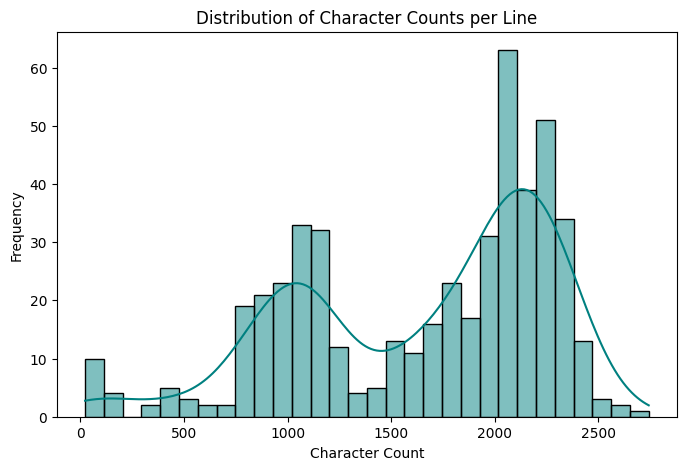

In [5]:
# 2️⃣ Basic text-level analysis
# -------------------------------------------------------------------------
data['char_count'] = data['text'].apply(len)
data['word_count'] = data['text'].apply(lambda x: len(str(x).split()))

print("\n📏 Text Statistics:")
print(data[['char_count', 'word_count']].describe())

# Plot character length distribution
plt.figure(figsize=(8,5))
sns.histplot(data['char_count'], bins=30, kde=True, color='teal')
plt.title("Distribution of Character Counts per Line")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()


🖼️ Sampling image dimensions...

📐 Average image height: 2012.34
📏 Average image width: 1445.08
🧮 Min width: 962, Max width: 4426


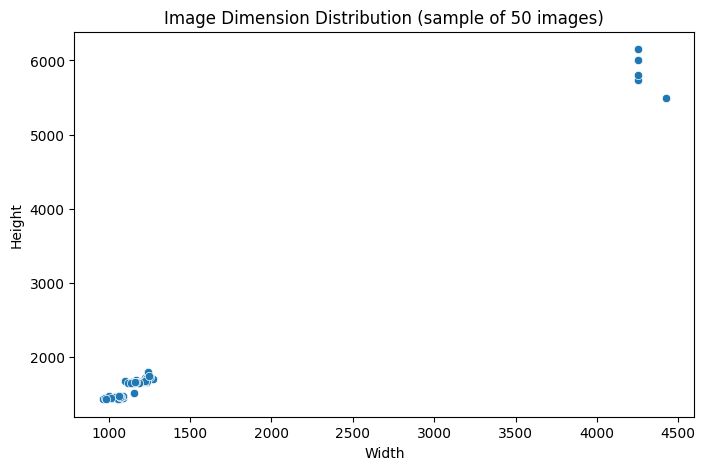

In [6]:
# 4️⃣ Image-level analysis
# -------------------------------------------------------------------------
image_heights = []
image_widths = []

print("\n🖼️ Sampling image dimensions...")

for i, row in data.sample(min(50, len(data))).iterrows():  # sample 50 random images
    img_path = row['image_path']
    if os.path.exists(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            h, w = img.shape
            image_heights.append(h)
            image_widths.append(w)

if image_heights:
    print(f"\n📐 Average image height: {np.mean(image_heights):.2f}")
    print(f"📏 Average image width: {np.mean(image_widths):.2f}")
    print(f"🧮 Min width: {np.min(image_widths)}, Max width: {np.max(image_widths)}")

    plt.figure(figsize=(8,5))
    sns.scatterplot(x=image_widths, y=image_heights)
    plt.title("Image Dimension Distribution (sample of 50 images)")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()


✨ Displaying random sample images with Sanskrit texts...


C:\Users\Mehak\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8756 (\N{THEREFORE}) missing from font(s) Nirmala UI.
  fig.canvas.print_figure(bytes_io, **kw)


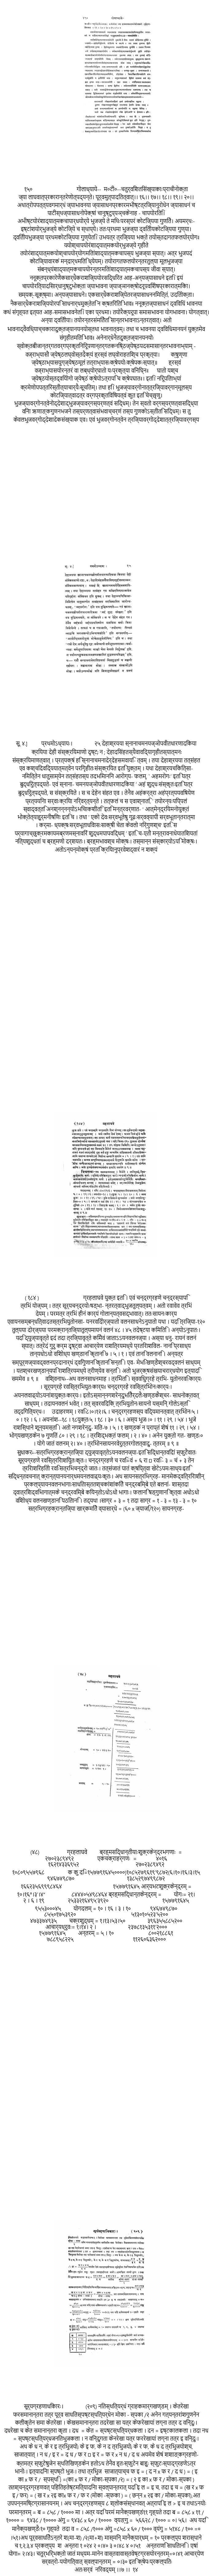

In [7]:
# 🪷 Font Setup
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

available_fonts = [f.name for f in font_manager.fontManager.ttflist]
if 'Nirmala UI' in available_fonts:
    plt.rcParams['font.family'] = 'Nirmala UI'
elif 'Mangal' in available_fonts:
    plt.rcParams['font.family'] = 'Mangal'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12

# ✨ Display random sample images with properly spaced text
print("\n✨ Displaying random sample images with Sanskrit texts...")

sample_rows = data.sample(5, random_state=42).reset_index(drop=True)

# Dynamically adjust figure height based on longest text length
max_text_len = max(len(str(row['text'])) for _, row in sample_rows.iterrows())
rows = len(sample_rows)
base_height = 4  # per image
extra_height = math.ceil(max_text_len / 150)  # add more height for long text
fig_height = rows * (base_height + extra_height)

plt.figure(figsize=(14, fig_height))

for idx, (_, row) in enumerate(sample_rows.iterrows()):
    img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
    if img is not None:
        ax = plt.subplot(rows, 1, idx + 1)
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        # Wrap long Sanskrit text into multiple lines
        wrapped_text = "\n".join(textwrap.wrap(str(row['text']), width=90))

        # Place text BELOW the image with enough margin
        ax.text(
            0.5, -0.25, wrapped_text,
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=12, fontweight='bold',
            wrap=True
        )

plt.subplots_adjust(hspace=2.8)  # more vertical space between plots
plt.show()


Preprocessing of the images 

1. forming the code for the same

In [8]:
class ImagePreprocessor:
    """
    Comprehensive preprocessing module for Sanskrit document images.
    Handles grayscale conversion, noise reduction, binarization, skew correction,
    and contrast enhancement.
    """
    
    def __init__(self):
        self.processed_image = None
        self.original_image = None
        
    def load_image(self, image_path):
        """Load image from file path."""
        self.original_image = cv2.imread(image_path)
        if self.original_image is None:
            raise ValueError(f"Could not load image from {image_path}")
        return self.original_image
    
    def convert_to_grayscale(self, image):
        """Convert RGB image to grayscale using luminance formula."""
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        return gray
    
    def reduce_noise(self, image, method='bilateral'):
        """
        Apply noise reduction filters.
        Methods: 'gaussian', 'bilateral', 'median'
        """
        if method == 'gaussian':
            denoised = cv2.GaussianBlur(image, (5, 5), 0)
        elif method == 'bilateral':
            # Edge-preserving filter - crucial for Devanagari ligatures
            denoised = cv2.bilateralFilter(image, 9, 75, 75)
        elif method == 'median':
            denoised = cv2.medianBlur(image, 5)
        else:
            denoised = image
        return denoised
    
    def binarize(self, image, method='adaptive'):
        """
        Convert grayscale to binary using various thresholding methods.
        """
        if method == 'otsu':
            _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        elif method == 'adaptive':
            # Adaptive thresholding - handles non-uniform illumination
            binary = cv2.adaptiveThreshold(
                image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                cv2.THRESH_BINARY, 11, 2
            )
        else:
            _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
        return binary
    
    def deskew(self, image):
        """
        Correct skew in scanned documents.
        Uses Hough transform to detect dominant angle.
        """
        # Calculate skew angle
        coords = np.column_stack(np.where(image < 128))
        if len(coords) == 0:
            return image, 0
        
        angle = cv2.minAreaRect(coords)[-1]
        
        # Adjust angle
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle
        
        # Rotate image
        (h, w) = image.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(
            image, M, (w, h),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REPLICATE
        )
        
        return rotated, angle
    
    def enhance_contrast(self, image):
        """
        Enhance contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization).
        Particularly useful for degraded manuscripts.
        """
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(image)
        return enhanced
    
    def preprocess_pipeline(self, image_path, visualize=False):
        """
        Complete preprocessing pipeline.
        
        Steps:
        1. Load image
        2. Convert to grayscale
        3. Enhance contrast
        4. Reduce noise
        5. Deskew
        6. Binarize
        
        Args:
            image_path: path to input image
            visualize: if True, displays intermediate results
            
        Returns:
            binary: final preprocessed binary image
        """
        print("\n" + "="*80)
        print(" "*25 + "PREPROCESSING")
        print("="*80)
        
        # Step 1: Load
        print("\n1. Loading image...")
        self.original_image = self.load_image(image_path)
        print(f"   Original size: {self.original_image.shape}")
        
        # Step 2: Grayscale
        print("2. Converting to grayscale...")
        gray = self.convert_to_grayscale(self.original_image)
        
        # Step 3: Enhance contrast
        print("3. Enhancing contrast (CLAHE)...")
        enhanced = self.enhance_contrast(gray)
        
        # Step 4: Noise reduction
        print("4. Reducing noise (bilateral filter)...")
        denoised = self.reduce_noise(enhanced, method='bilateral')
        
        # Step 5: Deskew
        print("5. Correcting skew...")
        deskewed, skew_angle = self.deskew(denoised)
        print(f"   Skew angle corrected: {skew_angle:.2f}°")
        
        # Step 6: Binarization
        print("6. Binarizing (adaptive threshold)...")
        binary = self.binarize(deskewed, method='adaptive')
        
        self.processed_image = binary
        
        if visualize:
            self.intermediate_results = {
                "original": self.original_image,
                "gray": gray,
                "enhanced": enhanced,
                "denoised": denoised,
                "deskewed": deskewed,
                "binary": binary,
                "skew_angle": skew_angle
            }
        print("✓ Preprocessing complete!\n")
        return binary


# Initialize preprocessor
preprocessor = ImagePreprocessor()
print("Preprocessor initialized successfully!")

Preprocessor initialized successfully!


2. Applying code to images

In [9]:
# Folder to save preprocessed images
output_dir = "preprocessed_images"
os.makedirs(output_dir, exist_ok=True)

print("\n🚀 Starting preprocessing for entire dataset...")
processed_records = []

for i, row in tqdm(data.iterrows(), total=len(data)):
    img_path = row['image_path']
    text = row['text']

    try:
        # Apply the full preprocessing pipeline
        processed_img = preprocessor.preprocess_pipeline(img_path, visualize=False)

        # Save processed image
        filename = os.path.basename(img_path)
        save_path = os.path.join(output_dir, filename)
        cv2.imwrite(save_path, processed_img)

        # Append processed record
        processed_records.append({
            'original_path': img_path,
            'processed_path': save_path,
            'text': text
        })

    except Exception as e:
        print(f"⚠️ Error processing {img_path}: {e}")

print("\n✅ Preprocessing complete!")
print(f"  ➤ Total processed images: {len(processed_records)} / {len(data)}")
print(f"  ➤ Saved to: {os.path.abspath(output_dir)}")

# Convert to DataFrame for later use
processed_df = pd.DataFrame(processed_records)
processed_df.to_csv("preprocessed_dataset.csv", index=False, encoding='utf-8')

print("\n💾 Saved processed dataset as 'preprocessed_dataset.csv'")


🚀 Starting preprocessing for entire dataset...


  0%|          | 2/494 [00:00<00:31, 15.45it/s]


                         PREPROCESSING

1. Loading image...
   Original size: (1439, 1044, 3)
2. Converting to grayscale...
3. Enhancing contrast (CLAHE)...
4. Reducing noise (bilateral filter)...
5. Correcting skew...
   Skew angle corrected: -88.78°
6. Binarizing (adaptive threshold)...
✓ Preprocessing complete!


                         PREPROCESSING

1. Loading image...
   Original size: (1474, 1061, 3)
2. Converting to grayscale...
3. Enhancing contrast (CLAHE)...
4. Reducing noise (bilateral filter)...
5. Correcting skew...
   Skew angle corrected: -12.94°
6. Binarizing (adaptive threshold)...
✓ Preprocessing complete!


                         PREPROCESSING

1. Loading image...
   Original size: (1449, 1019, 3)
2. Converting to grayscale...
3. Enhancing contrast (CLAHE)...
4. Reducing noise (bilateral filter)...
5. Correcting skew...
   Skew angle corrected: -0.28°
6. Binarizing (adaptive threshold)...
✓ Preprocessing complete!


                         PREPROCESSING

1. Loa

  1%|▏         | 7/494 [00:00<00:25, 19.31it/s]

5. Correcting skew...
   Skew angle corrected: -0.21°
6. Binarizing (adaptive threshold)...
✓ Preprocessing complete!


                         PREPROCESSING

1. Loading image...
   Original size: (1452, 1118, 3)
2. Converting to grayscale...
3. Enhancing contrast (CLAHE)...
4. Reducing noise (bilateral filter)...
5. Correcting skew...
   Skew angle corrected: -33.52°
6. Binarizing (adaptive threshold)...
✓ Preprocessing complete!


                         PREPROCESSING

1. Loading image...
   Original size: (1432, 1054, 3)
2. Converting to grayscale...
3. Enhancing contrast (CLAHE)...
4. Reducing noise (bilateral filter)...
5. Correcting skew...
   Skew angle corrected: -35.85°
6. Binarizing (adaptive threshold)...
✓ Preprocessing complete!


                         PREPROCESSING

1. Loading image...
   Original size: (1434, 1004, 3)
2. Converting to grayscale...
3. Enhancing contrast (CLAHE)...
4. Reducing noise (bilateral filter)...
5. Correcting skew...
   Skew angle corrected: 

...


                         PREPROCESSING

1. Loading image...
   Original size: (6351, 4250, 3)
2. Converting to grayscale...
3. Enhancing contrast (CLAHE)...
4. Reducing noise (bilateral filter)...
5. Correcting skew...
   Skew angle corrected: -87.69°
6. Binarizing (adaptive threshold)...
✓ Preprocessing complete!



100%|█████████▉| 493/494 [02:48<00:01,  1.61s/it]


                         PREPROCESSING

1. Loading image...
   Original size: (5593, 4250, 3)
2. Converting to grayscale...
3. Enhancing contrast (CLAHE)...
4. Reducing noise (bilateral filter)...
5. Correcting skew...
   Skew angle corrected: -85.78°
6. Binarizing (adaptive threshold)...
✓ Preprocessing complete!



100%|██████████| 494/494 [02:50<00:00,  2.90it/s]


✅ Preprocessing complete!
  ➤ Total processed images: 494 / 494
  ➤ Saved to: d:\Projects\Sanskrit-OCR\preprocessed_images

💾 Saved processed dataset as 'preprocessed_dataset.csv'


3. Line segmentation

In [10]:
# 🟢 GLOBAL CONFIG
IMG_HEIGHT = 32   # consistent with preprocessing + CRNN input
DATASET_ROOT = r"D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-Images-Annotation"

# =============================================================================
# CLASS DEFINITION
# =============================================================================

class LineSegmenter:
    """
    Automatic line segmentation for Sanskrit/Devanagari text
    using horizontal projection profiles.
    """

    def __init__(self, min_line_height=20, min_gap=5):
        self.min_line_height = min_line_height
        self.min_gap = min_gap

    def horizontal_projection(self, binary_image):
        """Calculate horizontal projection profile (sum of black pixels per row)."""
        return np.sum(binary_image == 0, axis=1)

    def detect_line_boundaries(self, projection):
        """Detect line boundaries from projection profile."""
        in_line = False
        start_row = 0
        boundaries = []
        for i, count in enumerate(projection):
            if count > 0 and not in_line:
                start_row = i
                in_line = True
            elif count == 0 and in_line:
                if i - start_row >= self.min_line_height:
                    boundaries.append((start_row, i))
                in_line = False
        if in_line and len(projection) - start_row >= self.min_line_height:
            boundaries.append((start_row, len(projection)))
        return boundaries

    def extract_lines(self, binary_image, boundaries):
        """Extract individual line images."""
        lines = []
        for idx, (start, end) in enumerate(boundaries):
            line_img = binary_image[start:end, :]
            lines.append({
                'image': line_img,
                'line_number': idx + 1,
                'y_start': start,
                'y_end': end,
                'height': end - start,
                'width': line_img.shape[1]
            })
        return lines

    def segment_lines(self, binary_image, normalize=True, target_height=IMG_HEIGHT):
        """Complete line segmentation pipeline."""
        print("\n" + "="*80)
        print(" "*25 + "LINE SEGMENTATION")
        print("="*80)

        projection = self.horizontal_projection(binary_image)
        boundaries = self.detect_line_boundaries(projection)
        print(f"   Found {len(boundaries)} text lines")

        lines = self.extract_lines(binary_image, boundaries)
        if normalize:
            for line in lines:
                h, w = line['image'].shape
                aspect_ratio = w / h
                new_width = int(target_height * aspect_ratio)
                resized = cv2.resize(line['image'], (new_width, target_height), interpolation=cv2.INTER_AREA)
                line['image'] = resized
                line['normalized_height'] = target_height
                line['normalized_width'] = new_width

        print(f"✓ Line segmentation complete! Extracted {len(lines)} lines\n")
        return lines

# Initialize segmenter
segmenter = LineSegmenter(min_line_height=20, min_gap=5)
print("✅ Line Segmenter initialized successfully!")

# =============================================================================
# APPLY LINE SEGMENTATION TO DATASET
# =============================================================================

def apply_line_segmentation_to_dataset(dataset_root, output_dir, sample_n=None, exts=('png','jpg','jpeg','tif','tiff')):
    """Run segmentation on all images under dataset_root."""
    os.makedirs(output_dir, exist_ok=True)
    image_files = []
    for root, _, files in os.walk(dataset_root):
        for f in files:
            if f.split('.')[-1].lower() in exts:
                image_files.append(os.path.join(root, f))

    image_files = sorted(image_files)
    if sample_n is not None:
        image_files = image_files[:sample_n]

    total_pages = len(image_files)
    total_lines = 0
    print(f"Processing {total_pages} pages from: {dataset_root}")

    for page_path in tqdm(image_files, desc="Segmenting pages"):
        try:
            img = cv2.imread(page_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            # Simple binarization
            blurred = cv2.GaussianBlur(img, (3, 3), 0)
            _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            if np.sum(binary == 0) / binary.size < 0.01:
                binary = 255 - binary
            lines = segmenter.segment_lines(binary, normalize=True, target_height=IMG_HEIGHT)
            base = os.path.splitext(os.path.basename(page_path))[0]
            out_page_dir = os.path.join(output_dir, base)
            os.makedirs(out_page_dir, exist_ok=True)
            for i, line in enumerate(lines, start=1):
                cv2.imwrite(os.path.join(out_page_dir, f"line_{i:03d}.png"), line['image'])
            total_lines += len(lines)
        except Exception as e:
            print(f"  Error processing {page_path}: {e}")

    print(f"✅ Done. Pages processed: {total_pages}. Total lines extracted: {total_lines}")
    return total_pages, total_lines


def preprocess_segmented_lines(segmented_root, preproc_root, img_height=IMG_HEIGHT, binarize=True):
    """Light preprocessing for all segmented line images."""
    os.makedirs(preproc_root, exist_ok=True)
    processed = 0
    for root, _, files in os.walk(segmented_root):
        rel_dir = os.path.relpath(root, segmented_root)
        out_dir = os.path.join(preproc_root, rel_dir)
        os.makedirs(out_dir, exist_ok=True)
        for f in files:
            if not f.lower().endswith('.png'):
                continue
            in_path = os.path.join(root, f)
            img = cv2.imread(in_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            if binarize:
                _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            h, w = img.shape
            new_w = max(1, int(img_height * (w / h)))
            resized = cv2.resize(img, (new_w, img_height), interpolation=cv2.INTER_AREA)
            cv2.imwrite(os.path.join(out_dir, f), resized)
            processed += 1
    print(f"✅ Preprocessing complete. Files processed: {processed}")
    return processed


def show_sample_segmentations(dataset_root, segmented_root, n_pages=3, max_lines_per_page=6):
    """Display n_pages original pages with their segmented line crops."""
    import random
    pages = []
    for root, _, files in os.walk(segmented_root):
        if files:
            pages.append((root, files))
    if not pages:
        print("⚠️ No segmented pages found.")
        return
    chosen = random.sample(pages, min(n_pages, len(pages)))
    for page_dir, files in chosen:
        base = os.path.basename(page_dir)
        orig = None
        for r, _, fs in os.walk(dataset_root):
            for f in fs:
                if os.path.splitext(f)[0] == base:
                    orig = cv2.imread(os.path.join(r, f), cv2.IMREAD_GRAYSCALE)
                    break
        if orig is not None:
            plt.figure(figsize=(10, 3))
            plt.imshow(orig, cmap='gray')
            plt.title(f'Original: {base}')
            plt.axis('off')
            plt.show()
        show_files = sorted(files)[:max_lines_per_page]
        cols = min(4, len(show_files))
        rows = int(np.ceil(len(show_files) / float(cols)))
        plt.figure(figsize=(cols * 3, rows * 1.8))
        for i, fname in enumerate(show_files):
            img = cv2.imread(os.path.join(page_dir, fname), cv2.IMREAD_GRAYSCALE)
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img, cmap='gray')
            plt.title(fname)
            plt.axis('off')
        plt.suptitle(f'Line crops for: {base}')
        plt.show()


def run_quick_segmentation_preview(sample_n=5):
    """Run a small preview for n pages to verify segmentation visually."""
    preview_dir = os.path.join(DATASET_ROOT, 'segmented_preview')
    preproc_dir = os.path.join(DATASET_ROOT, 'segmented_preproc_preview')
    pages, lines = apply_line_segmentation_to_dataset(DATASET_ROOT, preview_dir, sample_n=sample_n)
    print(f'Preview segmentation: pages={pages}, lines={lines}')
    processed = preprocess_segmented_lines(preview_dir, preproc_dir, img_height=IMG_HEIGHT)
    print(f'Preprocessed {processed} segmented lines into: {preproc_dir}')
    show_sample_segmentations(DATASET_ROOT, preview_dir, n_pages=3, max_lines_per_page=6)

print("\n✨ All line segmentation functions loaded successfully!")
print("To preview segmentation, run:\n  run_quick_segmentation_preview(sample_n=5)")

✅ Line Segmenter initialized successfully!

✨ All line segmentation functions loaded successfully!
To preview segmentation, run:
  run_quick_segmentation_preview(sample_n=5)


In [11]:
# =============================================================================
# APPLY LINE SEGMENTATION TO PREPROCESSED DATASET
# =============================================================================

# Make sure your processed dataset CSV exists
input_csv = "preprocessed_dataset.csv"
output_dir = "segmented_lines"
os.makedirs(output_dir, exist_ok=True)

# Load preprocessed dataset
data = pd.read_csv(input_csv)
print(f"\n📄 Loaded preprocessed dataset with {len(data)} samples")

# Initialize segmenter
segmenter = LineSegmenter(min_line_height=20, min_gap=5)
print("✅ Line Segmenter initialized successfully!")

segmented_records = []

print("\n🚀 Starting line segmentation for preprocessed images...")

for i, row in tqdm(data.iterrows(), total=len(data)):
    img_path = row['processed_path']
    text = row['text']

    try:
        # Load the image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"⚠️ Could not read {img_path}")
            continue

        # Segment lines
        lines = segmenter.segment_lines(img, normalize=True, target_height=32)

        # Save each segmented line
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        page_dir = os.path.join(output_dir, base_name)
        os.makedirs(page_dir, exist_ok=True)

        for j, line in enumerate(lines, start=1):
            line_filename = f"{base_name}_line{j:03d}.png"
            save_path = os.path.join(page_dir, line_filename)
            cv2.imwrite(save_path, line['image'])

            segmented_records.append({
                "original_image": img_path,
                "segmented_image": save_path,
                "line_number": j,
                "height": line['height'],
                "width": line['width'],
                "text": text  # later you can align with line-level text if needed
            })

    except Exception as e:
        print(f"⚠️ Error processing {img_path}: {e}")

# Convert to DataFrame and save
segmented_df = pd.DataFrame(segmented_records)
segmented_df.to_csv("segmented_dataset.csv", index=False, encoding='utf-8')

print("\n✅ Line segmentation complete!")
print(f"  ➤ Total lines extracted: {len(segmented_records)}")
print(f"  ➤ Segmented images saved to: {os.path.abspath(output_dir)}")
print(f"  ➤ CSV saved as 'segmented_dataset.csv'")


📄 Loaded preprocessed dataset with 494 samples
✅ Line Segmenter initialized successfully!

🚀 Starting line segmentation for preprocessed images...


  0%|          | 0/494 [00:00<?, ?it/s]


                         LINE SEGMENTATION


  1%|          | 3/494 [00:00<00:20, 24.52it/s]

   Found 1 text lines
✓ Line segmentation complete! Extracted 1 lines


                         LINE SEGMENTATION
   Found 2 text lines
✓ Line segmentation complete! Extracted 2 lines


                         LINE SEGMENTATION
   Found 1 text lines
✓ Line segmentation complete! Extracted 1 lines


                         LINE SEGMENTATION
   Found 5 text lines
✓ Line segmentation complete! Extracted 5 lines


                         LINE SEGMENTATION
   Found 1 text lines
✓ Line segmentation complete! Extracted 1 lines



...

100%|█████████▉| 493/494 [01:03<00:00,  3.62it/s]


                         LINE SEGMENTATION
   Found 2 text lines
✓ Line segmentation complete! Extracted 2 lines



100%|██████████| 494/494 [01:03<00:00,  7.78it/s]


                         LINE SEGMENTATION
   Found 1 text lines
✓ Line segmentation complete! Extracted 1 lines




✅ Line segmentation complete!
  ➤ Total lines extracted: 3467
  ➤ Segmented images saved to: d:\Projects\Sanskrit-OCR\segmented_lines
  ➤ CSV saved as 'segmented_dataset.csv'


Character mapping

In [12]:
# Define Devanagari Character Set for Sanskrit
DEVANAGARI_CHARS = [
    # Independent vowels
    'अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ऋ', 'ॠ', 'ऌ', 'ॡ', 'ए', 'ऐ', 'ओ', 'औ',
    # Consonants
    'क', 'ख', 'ग', 'घ', 'ङ',
    'च', 'छ', 'ज', 'झ', 'ञ',
    'ट', 'ठ', 'ड', 'ढ', 'ण',
    'त', 'थ', 'द', 'ध', 'न',
    'प', 'फ', 'ब', 'भ', 'म',
    'य', 'र', 'ल', 'व',
    'श', 'ष', 'स', 'ह',
    # Vowel diacritics (matras)
    'ा', 'ि', 'ी', 'ु', 'ू', 'ृ', 'ॄ', 'ॢ', 'ॣ', 'े', 'ै', 'ो', 'ौ',
    # Special characters
    'ं', 'ः', '्', 'ँ', 'ऽ',
    # Numerals
    '०', '१', '२', '३', '४', '५', '६', '७', '८', '९',
    # Punctuation
    '।', '॥',
    # Space and common symbols
    ' ', '.', ',', '-', '?', '!',
]

# Create character to index mapping
char2idx = {char: idx + 1 for idx, char in enumerate(DEVANAGARI_CHARS)}  # 0 reserved for CTC blank
idx2char = {idx: char for char, idx in char2idx.items()}
idx2char[0] = '<BLANK>'  # CTC blank token

VOCAB_SIZE = len(char2idx) + 1  # +1 for blank token

print(f"Devanagari Vocabulary Size: {VOCAB_SIZE}")
print(f"Total Characters: {len(DEVANAGARI_CHARS)}")
print(f"Sample Characters: {DEVANAGARI_CHARS[:20]}")

Devanagari Vocabulary Size: 84
Total Characters: 83
Sample Characters: ['अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ऋ', 'ॠ', 'ऌ', 'ॡ', 'ए', 'ऐ', 'ओ', 'औ', 'क', 'ख', 'ग', 'घ', 'ङ', 'च']


CRNN Model

In [13]:
class CRNN(nn.Module):
    """
    Convolutional Recurrent Neural Network for Sanskrit OCR.
    Architecture: CNN (Feature Extraction) → Bi-LSTM (Sequence Modeling) → FC (Classification)
    """
    
    def __init__(self, img_height, num_channels, num_classes, rnn_hidden=256, num_rnn_layers=2):
        super(CRNN, self).__init__()
        
        self.img_height = img_height
        self.num_classes = num_classes
        
        # Convolutional Backbone for Feature Extraction
        # Input: (batch, 1, height, width)
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(num_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # H/2
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # H/4
            
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Block 4
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),  # H/8, W unchanged
            
            # Block 5
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            
            # Block 6
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),  # H/16, W unchanged
        )
        
        # Calculate CNN output size
        self.cnn_output_height = img_height // 16  # Due to pooling
        self.cnn_output_channels = 512
        
        # Map to sequence
        self.map_to_seq = nn.Linear(self.cnn_output_height * self.cnn_output_channels, 
                                     rnn_hidden)
        
        # Bidirectional LSTM layers for sequence modeling
        self.rnn = nn.LSTM(
            rnn_hidden, 
            rnn_hidden, 
            num_rnn_layers, 
            bidirectional=True,
            batch_first=True,
            dropout=0.3 if num_rnn_layers > 1 else 0
        )
        
        # Fully connected layer for classification
        self.fc = nn.Linear(rnn_hidden * 2, num_classes)  # *2 for bidirectional
        
    def forward(self, x):
        """
        Forward pass through CRNN.
        Input: (batch, channels, height, width)
        Output: (sequence_length, batch, num_classes) for CTC loss
        """
        # CNN feature extraction
        conv_features = self.cnn(x)  # (batch, 512, H/16, W)
        
        # Reshape to sequence
        batch, channels, height, width = conv_features.size()
        conv_features = conv_features.permute(0, 3, 1, 2)  # (batch, W, 512, H/16)
        conv_features = conv_features.reshape(batch, width, -1)  # (batch, W, 512*H/16)
        
        # Map to RNN input size
        seq_features = self.map_to_seq(conv_features)  # (batch, W, rnn_hidden)
        
        # LSTM sequence modeling
        rnn_output, _ = self.rnn(seq_features)  # (batch, W, rnn_hidden*2)
        
        # Classification
        output = self.fc(rnn_output)  # (batch, W, num_classes)
        
        # Permute for CTC loss: (W, batch, num_classes)
        output = output.permute(1, 0, 2)
        
        return output
    
    def predict(self, x):
        """
        Prediction with log softmax for CTC decoding.
        """
        output = self.forward(x)
        return F.log_softmax(output, dim=2)


# Initialize CRNN model
IMG_HEIGHT = 32
NUM_CHANNELS = 1  # Grayscale
model = CRNN(
    img_height=IMG_HEIGHT,
    num_channels=NUM_CHANNELS,
    num_classes=VOCAB_SIZE,
    rnn_hidden=256,
    num_rnn_layers=2
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*60)
print("CRNN Model Architecture")
print("="*60)
print(f"Image Height: {IMG_HEIGHT}")
print(f"Number of Channels: {NUM_CHANNELS}")
print(f"Vocabulary Size: {VOCAB_SIZE}")
print(f"RNN Hidden Size: 256")
print(f"Number of RNN Layers: 2")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print("="*60)
print("\nModel Components:")
print("  1. CNN Backbone (6 blocks): Feature extraction from line images")
print("  2. Bi-LSTM (2 layers): Sequence modeling with context")
print("  3. Fully Connected: Character classification")
print("  4. CTC Loss: Alignment-free training")
print("="*60)

CRNN Model Architecture
Image Height: 32
Number of Channels: 1
Vocabulary Size: 84
RNN Hidden Size: 256
Number of RNN Layers: 2
Total Parameters: 7,438,292
Trainable Parameters: 7,438,292

Model Components:
  1. CNN Backbone (6 blocks): Feature extraction from line images
  2. Bi-LSTM (2 layers): Sequence modeling with context
  3. Fully Connected: Character classification
  4. CTC Loss: Alignment-free training


CTC Encoder with beam search + OCR Engine

In [14]:
class CTCDecoder:
    """
    CTC Decoder with beam search for converting model predictions to text.
    Implements both greedy and beam search decoding strategies.
    """
    
    def __init__(self, char_list, blank_index=0):
        self.char_list = char_list
        self.blank_index = blank_index
        
    def greedy_decode(self, predictions, confidence_threshold=0.5):
        """
        Greedy CTC decoding: selects most probable character at each timestep.
        
        Args:
            predictions: (seq_length, num_classes) - log probabilities
            confidence_threshold: minimum confidence to include character
            
        Returns:
            decoded_text: string
            confidence_scores: list of confidence values
        """
        # Get most probable class at each timestep
        pred_indices = torch.argmax(predictions, dim=1).cpu().numpy()
        confidences = torch.softmax(predictions, dim=1).max(dim=1)[0].cpu().numpy()
        
        # Remove consecutive duplicates and blanks
        decoded = []
        conf_scores = []
        prev_idx = None
        
        for idx, conf in zip(pred_indices, confidences):
            if idx != self.blank_index and idx != prev_idx:
                if conf >= confidence_threshold:
                    if idx in self.char_list:
                        decoded.append(self.char_list[idx])
                        conf_scores.append(float(conf))
            prev_idx = idx
        
        decoded_text = ''.join(decoded)
        return decoded_text, conf_scores
    
    def beam_search_decode(self, predictions, beam_width=5):
        """
        Beam search CTC decoding for better accuracy.
        
        Args:
            predictions: (seq_length, num_classes) - log probabilities
            beam_width: number of beams to maintain
            
        Returns:
            best_text: decoded string
            best_score: confidence score
        """
        predictions = predictions.cpu().numpy()
        seq_len, num_classes = predictions.shape
        
        # Initialize beam with empty sequence
        beams = [([''], 0.0)]  # (sequence, score)
        
        for t in range(seq_len):
            new_beams = {}
            
            for seq, score in beams:
                # For each class at timestep t
                for c in range(num_classes):
                    prob = predictions[t, c]
                    new_score = score + prob
                    
                    if c == self.blank_index:
                        # Blank: extend current sequence
                        key = tuple(seq)
                        if key not in new_beams or new_beams[key] < new_score:
                            new_beams[key] = new_score
                    else:
                        # Character
                        char = self.char_list.get(c, '')
                        if char:
                            # Extend with new character
                            new_seq = seq.copy()
                            if len(seq) > 0 and seq[-1] == char:
                                # Same as previous, need blank in between
                                pass
                            else:
                                new_seq.append(char)
                            
                            key = tuple(new_seq)
                            if key not in new_beams or new_beams[key] < new_score:
                                new_beams[key] = new_score
            
            # Keep top beam_width beams
            beams = sorted(new_beams.items(), key=lambda x: x[1], reverse=True)[:beam_width]
            beams = [(list(k), v) for k, v in beams]
        
        # Return best beam
        if beams:
            best_seq, best_score = beams[0]
            return ''.join(best_seq[1:]), best_score  # Skip initial empty string
        return '', 0.0


class OCREngine:
    """
    Complete OCR Engine integrating model inference and decoding.
    """
    
    def __init__(self, model, decoder, device='cpu'):
        self.model = model
        self.decoder = decoder
        self.device = device
        self.model.to(device)
        self.model.eval()
        
    def preprocess_line(self, line_image, target_height=32):
        """
        Preprocess line image for model input.
        """
        # Ensure grayscale
        if len(line_image.shape) == 3:
            line_image = cv2.cvtColor(line_image, cv2.COLOR_BGR2GRAY)
        
        # Normalize to target height
        h, w = line_image.shape
        new_width = int(w * target_height / h)
        resized = cv2.resize(line_image, (new_width, target_height))
        
        # Normalize pixel values to [0, 1]
        normalized = resized.astype(np.float32) / 255.0
        
        # Add batch and channel dimensions: (1, 1, H, W)
        tensor = torch.from_numpy(normalized).unsqueeze(0).unsqueeze(0)
        
        return tensor
    
    def recognize_line(self, line_image, method='greedy'):
        """
        Recognize text from a single line image.
        
        Args:
            line_image: numpy array (H, W) or (H, W, C)
            method: 'greedy' or 'beam_search'
            
        Returns:
            text: recognized text string
            confidence: average confidence score
        """
        # Preprocess
        input_tensor = self.preprocess_line(line_image).to(self.device)
        
        # Model inference
        with torch.no_grad():
            predictions = self.model.predict(input_tensor)  # (seq_len, 1, num_classes)
            predictions = predictions.squeeze(1)  # (seq_len, num_classes)
        
        # Decode
        if method == 'greedy':
            text, conf_scores = self.decoder.greedy_decode(predictions)
            avg_confidence = np.mean(conf_scores) if conf_scores else 0.0
        elif method == 'beam_search':
            text, score = self.decoder.beam_search_decode(predictions, beam_width=5)
            avg_confidence = score / len(text) if len(text) > 0 else 0.0
        else:
            raise ValueError(f"Unknown decoding method: {method}")
        
        return text, avg_confidence
    
    def recognize_document(self, line_images, method='greedy'):
        """
        Recognize text from multiple line images.
        
        Args:
            line_images: list of line image dictionaries
            method: decoding method
            
        Returns:
            results: list of recognition results
        """
        print(f"\nStage 2: OCR Recognition ({method} decoding)")
        print("="*60)
        
        results = []
        for idx, line_data in enumerate(line_images):
            line_img = line_data['image']
            
            # Recognize
            text, confidence = self.recognize_line(line_img, method=method)
            
            result = {
                'line_number': line_data['line_number'],
                'text': text,
                'confidence': confidence,
                'width': line_data['width'],
                'height': line_data['height']
            }
            results.append(result)
            
            print(f"Line {result['line_number']:2d}: {text[:50]}... (conf: {confidence:.3f})")
        
        print("="*60)
        print(f"✓ Recognized {len(results)} lines\n")
        return results


# Initialize decoder and OCR engine
decoder = CTCDecoder(char_list=idx2char, blank_index=0)
ocr_engine = OCREngine(
    model=model, 
    decoder=decoder, 
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print("OCR Engine initialized successfully!")
print(f"Device: {ocr_engine.device}")

OCR Engine initialized successfully!
Device: cpu


Training configuration

In [15]:
class SanskritDataset(Dataset):
    """
    Custom Dataset for Sanskrit OCR.
    Loads line images and corresponding text labels from a CSV file.
    CSV columns required: ['image_path', 'text']
    """

    def __init__(self, csv_path, char2idx, img_height=32, transform=None):
        self.data = pd.read_csv(csv_path)
        self.char2idx = char2idx
        self.img_height = img_height
        self.transform = transform

        # Remove missing rows
        self.data = self.data.dropna(subset=['image_path', 'text']).reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def text_to_labels(self, text):
        """Convert a Sanskrit text string into numeric label indices."""
        return [self.char2idx.get(ch, 0) for ch in text if ch in self.char2idx]

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row['image_path']
        text = str(row['text'])

        # Read grayscale image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Could not read image: {image_path}")

        # Resize (maintaining aspect ratio)
        h, w = img.shape
        new_w = int(w * (self.img_height / h))
        img = cv2.resize(img, (new_w, self.img_height))

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)  # (1, H, W)

        # Convert text to label indices
        label = torch.tensor(self.text_to_labels(text), dtype=torch.int32)

        # Approximate input length after CNN downsampling
        input_length = img.shape[-1] // 4
        label_length = len(label)

        return {
            'image': img,
            'label': label,
            'input_length': input_length,
            'label_length': label_length,
            'text': text,
            'image_path': image_path
        }

print("✅ SanskritDataset class loaded successfully!")

✅ SanskritDataset class loaded successfully!


In [16]:
class CTCTrainer:
    """
    Trainer class for CRNN model with CTC loss.
    """

    def __init__(self, model, train_loader, val_loader, device, char2idx, idx2char):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.char2idx = char2idx
        self.idx2char = idx2char

        # Loss function
        self.criterion = nn.CTCLoss(blank=0, zero_infinity=True)

        # Optimizer & scheduler
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3, verbose=True
        )

        # Tracking
        self.train_losses, self.val_losses = [], []
        self.best_val_loss = float('inf')

    def train_epoch(self):
        self.model.train()
        epoch_loss = 0
        for batch in self.train_loader:
            images = batch['image'].to(self.device)
            labels = batch['label']
            input_lengths = batch['input_length']
            label_lengths = batch['label_length']

            self.optimizer.zero_grad()

            outputs = self.model(images)
            log_probs = F.log_softmax(outputs, dim=2)

            loss = self.criterion(log_probs, labels, input_lengths, label_lengths)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
            self.optimizer.step()

            epoch_loss += loss.item()
        return epoch_loss / len(self.train_loader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in self.val_loader:
                images = batch['image'].to(self.device)
                labels = batch['label']
                input_lengths = batch['input_length']
                label_lengths = batch['label_length']

                outputs = self.model(images)
                log_probs = F.log_softmax(outputs, dim=2)
                loss = self.criterion(log_probs, labels, input_lengths, label_lengths)
                val_loss += loss.item()
        return val_loss / len(self.val_loader)

    def train(self, num_epochs, save_dir='checkpoints'):
        os.makedirs(save_dir, exist_ok=True)
        print("="*80)
        print(" "*25 + "TRAINING START")
        print("="*80)
        print(f"Device: {self.device}")
        print(f"Epochs: {num_epochs}")
        print("="*80)

        for epoch in range(1, num_epochs + 1):
            train_loss = self.train_epoch()
            val_loss = self.validate()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.scheduler.step(val_loss)

            print(f"Epoch [{epoch}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                torch.save(self.model.state_dict(), os.path.join(save_dir, 'best_model.pth'))
                print(f"  ✓ Saved best model (val_loss: {val_loss:.4f})")

        print("="*80)
        print(" "*25 + "TRAINING COMPLETE")
        print("="*80)
        print(f"Best Validation Loss: {self.best_val_loss:.4f}")

    def plot_training_history(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training & Validation Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

print("✅ CTCTrainer class loaded successfully!")

✅ CTCTrainer class loaded successfully!


In [17]:
df = pd.read_csv("segmented_dataset.csv")
print(df.columns)
print(df.head())

Index(['original_image', 'segmented_image', 'line_number', 'height', 'width',
       'text'],
      dtype='object')
                      original_image  \
0  preprocessed_images\page-001.jpeg   
1  preprocessed_images\page-002.jpeg   
2  preprocessed_images\page-002.jpeg   
3  preprocessed_images\page-003.jpeg   
4  preprocessed_images\page-004.jpeg   

                                 segmented_image  line_number  height  width  \
0  segmented_lines\page-001\page-001_line001.png            1     678   1044   
1  segmented_lines\page-002\page-002_line001.png            1      37   1072   
2  segmented_lines\page-002\page-002_line002.png            2     337   1072   
3  segmented_lines\page-003\page-003_line001.png            1     853   1273   
4  segmented_lines\page-004\page-004_line001.png            1      24   1145   

                                                text  
0  THE WORKS OF\n\nSri Sankaracharya\n\nSRI VANI ...  
1  परिग्रहण सं. १०३६३\nग्रन्थालय, के. उ. ति. शि. ...

In [18]:
# Load and rename
df = pd.read_csv("segmented_dataset.csv")
df = df.rename(columns={'segmented_image': 'image_path'})
df.to_csv("segmented_dataset.csv", index=False)

print("✅ CSV column renamed successfully!")
print(df.columns)


✅ CSV column renamed successfully!
Index(['original_image', 'image_path', 'line_number', 'height', 'width',
       'text'],
      dtype='object')


In [19]:
def collate_fn(batch):
    """
    Custom collate function for variable-width line images.
    Pads each image in the batch to the max width and computes CTC input lengths.
    """
    images = [item['image'] for item in batch]
    labels = [item['label'] for item in batch]
    label_lengths = [item['label_length'] for item in batch]

    # Find max width in this batch
    max_w = max(img.shape[-1] for img in images)

    # Pad all images to same width
    padded_images = []
    input_lengths = []
    for img in images:
        _, h, w = img.shape
        pad_w = max_w - w
        padded = F.pad(img, (0, pad_w, 0, 0), value=1.0)
        padded_images.append(padded)

        # Compute approximate input length (number of time steps after CNN)
        # Since CNN downsamples width by factor ~4 (from 2x2 + 2x2 pooling)
        # adjust according to your CRNN structure (here width stays same mostly)
        input_len = max_w // 4  # adjust if your CNN downsamples more/less
        input_lengths.append(input_len)

    images_tensor = torch.stack(padded_images)
    labels_concat = torch.cat(labels)
    label_lengths_tensor = torch.tensor(label_lengths, dtype=torch.long)
    input_lengths_tensor = torch.tensor(input_lengths, dtype=torch.long)

    return {
        'image': images_tensor,
        'label': labels_concat,
        'label_length': label_lengths_tensor,
        'input_length': input_lengths_tensor
    }


                         TRAINING CONFIGURATION
Dataset: segmented_dataset.csv
Batch Size: 8
Epochs: 2
Device: cpu
Train samples: 2773, Val samples: 694
                         TRAINING START
Device: cpu
Epochs: 2


c:\Users\Mehak\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/2] | Train Loss: 0.4628 | Val Loss: 0.4681
  ✓ Saved best model (val_loss: 0.4681)
Epoch [2/2] | Train Loss: 0.4310 | Val Loss: 0.5352
                         TRAINING COMPLETE
Best Validation Loss: 0.4681


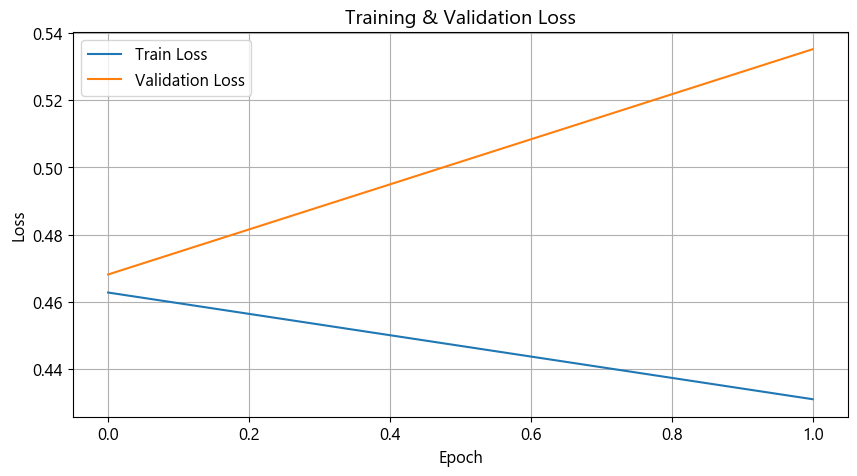

In [21]:
# =============================================================================
# TRAINING CONFIGURATION
# =============================================================================

DATASET_CSV = "segmented_dataset.csv"  # <-- Update this to your CSV file
BATCH_SIZE = 8
NUM_EPOCHS = 2
IMG_HEIGHT = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print("="*80)
print(" "*25 + "TRAINING CONFIGURATION")
print("="*80)
print(f"Dataset: {DATASET_CSV}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Device: {DEVICE}")
print("="*80)

# Step 1: Load dataset
dataset = SanskritDataset(csv_path=DATASET_CSV, char2idx=char2idx, img_height=IMG_HEIGHT)

# Split into train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

# Step 2: Initialize Trainer
trainer = CTCTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    char2idx=char2idx,
    idx2char=idx2char
)

# Step 3: Start training
trainer.train(num_epochs=NUM_EPOCHS, save_dir='checkpoints')

# Step 4: Plot results
trainer.plot_training_history()
